In [1]:
import json
import numpy as np
from utils import json_to_xml
from utils import utils
import ants
import pandas as pd
from pathlib import Path
import os

In [49]:
# Load QC data to identify the appropriate samples / channels
thDatasets = pd.read_csv("../scratch/241113 Thalamus QC.csv").iloc[:,0:6]
thDatasets = thDatasets[thDatasets["Tissue QC"] == "Pass"]
print("Number of potentially passing injections:", sum(thDatasets["Inj 1 QC"].isin(["Check","Pass"])) + sum(thDatasets["Inj 2 QC"].isin(["Check","Pass"])) + sum(thDatasets["Inj 3 QC"].isin(["Check","Pass"])))

Number of potentially passing injections: 103


In [50]:
# Setup dictionaries to convert between injection numbers and data channels
wtLUT = {"Inj 1 QC":445, "Inj 2 QC":561, "Inj 3 QC":488} # incorrect assumption for rabies brains
ai224LUT = {"Inj 1 QC":488, "Inj 2 QC":561}
genotypeLUT = {"WT":wtLUT,"Ai224":ai224LUT}

In [51]:
# Collect potential QC passing channels
sampleDict = {}
for indx in range(len(thDatasets)):
    # Find which injections are not outright fails
    useColumns = thDatasets.iloc[indx,3:].isin(["Pass","Check"])
    useColumns = useColumns[useColumns].index.tolist()
    # A handful of older datasets have not yet been brought up to current formatting conventions
    if thDatasets.iloc[indx,0] in [674189, 676742, 681224, 681225, 681226, 681227, 675376]:
        continue
    if thDatasets.iloc[indx,0] in [677289, 677290, 679517, 679516]: # direct registration exceptions
        continue
    elif thDatasets.iloc[indx,0] in [698927, 698928, 693977, 693978, 693979, 693980]: # rabies exceptions
        sampleDict[thDatasets.iloc[indx,0]] = [488, 561]
        continue
    # If there are usable injections, use genotype information to infer injection's spectral channel
    if useColumns:
        sampleDict[thDatasets.iloc[indx,0]] = [genotypeLUT[thDatasets.iloc[indx,1]][col] for col in useColumns]
    

In [39]:
thDatasets

,Mouse ID,Genotype,Tissue QC,Inj 1 QC,Inj 2 QC,Inj 3 QC
7,674189,WT,Pass,Fail,Check,NaN
8,676742,WT,Pass,Fail,Check,NaN
24,681224,WT,Pass,Fail,Check,NaN
25,681225,WT,Pass,Fail,Check,NaN
26,681226,WT,Pass,Fail,Check,NaN
...,...,...,...,...,...,...
102,757188,WT,Pass,NaN,Pass,Pass
103,757189,WT,Pass,NaN,Pass,Pass
104,757190,WT,Pass,NaN,Pass,Pass
105,758792,WT,Pass,NaN,Pass,Pass


In [ ]:
[674189,  676742, 681224,  681225,  681226, 681227, 675376, 677289, 677290, 679516, 679517, 679519, 679521, 679518, 685904, 685906, 687219, 687220, 685110,
 687218,  687221, 677291, 691386, 693197, 693198, 685111, 687502, 694513, 693196, 698034, 692913, 725326, 743800, 743801, 743709, 741535, 754626, 754627, 755807,
 755808, 755809, 757188, 757189, 757190, 758792, 758793]

In [ ]:
{693197: {445: [1184.0, 2368.0, 4032.0],
  561: [1528.0, 2720.0, 4056.0],
  488: [1392.0, 2224.0, 4040.0]},
 693198: {445: [1496.0, 2144.0, 4576.0],
  561: [1848.0, 2128.0, 4136.0],
  488: [1792.0, 2000.0, 4296.0]},
 698034: {445: [2480.0, 1640.0, 4728.0],
  561: [3032.0, 2320.0, 5144.0],
  488: [2128.0, 2112.0, 3784.0]},
 743800: {561: [1288.0, 2064.0, 5040.0], 488: [1776.0, 2136.0, 4880.0]},
 743801: {561: [1264.0, 2560.0, 5072.0], 488: [1184.0, 1792.0, 4632.0]},
 754626: {561: [1640.0, 2624.0, 5160.0], 488: [2056.0, 3112.0, 5072.0]},
 754627: {561: [1376.0, 2816.0, 4568.0]},
 755809: {561: [1016.0, 2352.0, 4936.0], 488: [944.0, 3472.0, 3784.0]},
 757188: {561: [896.0, 3272.0, 3912.0], 488: [1696.0, 2776.0, 5128.0]},
 757189: {561: [1088.0, 3352.0, 3864.0], 488: [1064.0, 3072.0, 3912.0]},
 757190: {561: [2000.0, 2992.0, 2240.0], 488: [1832.0, 1920.0, 4776.0]},
 758792: {561: [1032.0, 3248.0, 4952.0], 488: [1344.0, 2680.0, 5008.0]},
 758793: {561: [2056.0, 2784.0, 4656.0], 488: [1984.0, 3216.0, 5192.0]}}


In [28]:
# sampleDict

In [5]:
# Setup variables for CCF transformation and plotting
channelDict = {445: 'Ex_445_Em_469', 488:'Ex_488_Em_525', 561:'Ex_561_Em_593'}
orient_lut = {"A": "AP", "P": "AP", "S": "DV", "I": "DV", "R": "ML", "L": "ML"}   
centroid = 'centroid.xml'
img = ants.image_read('/data/lightsheet_template_ccf_registration/ccf_average_template_25.nii.gz')
img = img.numpy()

## Use different coordDicts

In [6]:
# # WT AAVrg
coordDict = {693197: {445: [1184.0, 2368.0, 4032.0],
  561: [1528.0, 2720.0, 4056.0],
  488: [1392.0, 2224.0, 4040.0]},
 693198: {445: [1496.0, 2144.0, 4576.0],
  561: [1848.0, 2128.0, 4136.0],
  488: [1792.0, 2000.0, 4296.0]},
 698034: {445: [2480.0, 1640.0, 4728.0],
  561: [3032.0, 2320.0, 5144.0],
  488: [2128.0, 2112.0, 3784.0]},
 743800: {561: [1288.0, 2064.0, 5040.0], 488: [1776.0, 2136.0, 4880.0]},
 743801: {561: [1264.0, 2560.0, 5072.0], 488: [1184.0, 1792.0, 4632.0]},
 754626: {561: [1640.0, 2624.0, 5160.0], 488: [2056.0, 3112.0, 5072.0]},
 754627: {561: [1376.0, 2816.0, 4568.0]},
 755809: {561: [1016.0, 2352.0, 4936.0], 488: [944.0, 3472.0, 3784.0]},
 757188: {561: [896.0, 3272.0, 3912.0], 488: [1696.0, 2776.0, 5128.0]},
 757189: {561: [1088.0, 3352.0, 3864.0], 488: [1064.0, 3072.0, 3912.0]},
 757190: {561: [2000.0, 2992.0, 2240.0], 488: [1832.0, 1920.0, 4776.0]},
 758792: {561: [1032.0, 3248.0, 4952.0], 488: [1344.0, 2680.0, 5008.0]},
 758793: {561: [2056.0, 2784.0, 4656.0], 488: [1984.0, 3216.0, 5192.0]}}


In [54]:
# More AAVrg
coordDict = {
743709: {488: [1880.0, 2592.0, 2880.0], 561: [1784.0, 2608.0, 2616.0]},
755807: {488: [2016.0, 2480.0, 4232.0], 561: [1832.0, 2712.0, 2392.0]},
755808: {488: [1432.0, 2328.0, 4656.0], 561: [1640.0, 2112.0, 4616.0]}
}

In [ ]:
# # Ai224 AAVrg #real
# coordDict = {
# 677289: {561: [1465, 2679, 4476]}, # direct
# 677290: {561: [1320, 2297, 3932]}, # direct
# 679516: {488: [1174, 1975, 4370], 561: [1688, 2353, 4116]},
# 679517: {561: [1469, 3124, 4657]}, # direct
# 679519: {561: [1607, 2270, 4499]},
# 685111: {561: [1407, 2479, 4068]},
# 692913: {488: [2337, 1984, 4446], 561: [2097, 2393, 4362]}
# }

In [55]:
coordDict

{743709: {488: [1880.0, 2592.0, 2880.0], 561: [1784.0, 2608.0, 2616.0]},
 755807: {488: [2016.0, 2480.0, 4232.0], 561: [1832.0, 2712.0, 2392.0]},
 755808: {488: [1432.0, 2328.0, 4656.0], 561: [1640.0, 2112.0, 4616.0]}}

In [59]:
sampleDict[755808] = [488, 561]

In [60]:
# sampleList = coordDict.keys()
sampleList = [sample for sample in coordDict.keys() if sample in sampleDict.keys()]
ccfDict = {}

In [61]:
for name in sampleList:
    print(name)

743709
755807
755808


In [63]:
rootDir = Path('../data')
for sample in sampleList:
    # get image info
    data_root = [file for file in rootDir.iterdir() if str(sample) in str(file)][0]
    # data_root = '../data/SmartSPIM_721832_2024-03-29_19-37-36_stitched_2024-04-05_09-23-40'
    # channel = 'Ex_488_Em_525'

    print(str(sample))
    if os.path.exists(f"{data_root}/acquisition.json"):
        # Load acquisition orientation
        with open(f"{data_root}/acquisition.json", 'r') as fp:
            data = json.load(fp)

        orientation = ["", "", ""]
        allen_orient = ["", "", ""]
        for axis in data['axes']:
            axis_val = axis['dimension']
            axis_name = axis['direction']
            orientation[int(axis_val)] = axis_name[0]
            allen_orient[int(axis_val)] = orient_lut[axis_name[0]]

        print(f"Data orientation in neuroglancer zyx: {''.join(orientation)} {tuple(allen_orient)}")
    else:
        orientation = ["SAL"]
        allen_orient = ['DV', 'AP', 'ML']
        print(f"Could not find acquisition.json. Assuming: {''.join(orientation)} {tuple(allen_orient)}")

    #set point of interest and save to .xml (this is just beacuse I don't fell like rewriting the registration function)
    cellDict = {}
    for ch in sampleDict[sample]:
        channel = channelDict[ch]
        interest_pt = {'centroid': [coordDict[sample][ch]]} #z,y,x from neuroglancer

        json_to_xml.dict_to_xml(interest_pt, centroid)

        params = {
            "cells_path": '../results/centroid.xml',
            "data_path": data_root,
            "channel": channel,
            "transforms_path": '../data/lightsheet_template_ccf_registration/',
            "orient": ''.join(orientation),
            "template_orient": 'RAS',
            "institute_abbreviation": 'AIND',
            "input_level": 0,
            "register_level": 3,
        }

        _, cells_ccf = utils.transform_cells(params)
        cellDict[ch] = list(cells_ccf[0, :].astype(int))
    ccfDict[sample] = cellDict
    

    # # origin of the ML axis is opposite for registration so need to flip
    # img = ants.image_read('/data/lightsheet_template_ccf_registration/ccf_average_template_25.nii.gz')

    # for axis, label in enumerate(img.orientation):
    #     if orient_lut[label] == "ML":
    #         flip_axis = axis 

    # cells_ccf[:, flip_axis] = img.shape[flip_axis] - cells_ccf[:, flip_axis]
    # cells_ccf[0, :].astype(int)

743709
Data orientation in neuroglancer zyx: IAR ('DV', 'AP', 'ML')
Saving cells to ../results/centroid.xml
[415, 1101, 928]


IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

In [10]:
ccfDict

{693197: {445: [119, 101, 216], 561: [143, 128, 211], 488: [109, 118, 213]},
 693198: {445: [130, 89, 157], 561: [122, 106, 193], 488: [114, 103, 181]},
 698034: {445: [184, 231, 460], 561: [228, 283, 486], 488: [214, 205, 392]},
 743800: {561: [114, 115, 323], 488: [116, 162, 309]},
 743801: {561: [190, 147, 335], 488: [128, 137, 305]},
 754626: {561: [129, 128, 326], 488: [161, 166, 318]},
 754627: {561: [144, 103, 277]},
 755809: {561: [120, 140, 319], 488: [187, 103, 239]},
 757188: {561: [176, 97, 241], 488: [148, 175, 326]},
 757189: {561: [183, 96, 237], 488: [163, 93, 240]},
 757190: {561: [136, 140, 139], 488: [94, 159, 315]},
 758792: {561: [181, 75, 309], 488: [141, 98, 314]},
 758793: {561: [140, 154, 303], 488: [173, 154, 336]}}

In [22]:
ccfDict

{693197: {445: [119, 101, 216], 561: [143, 128, 211], 488: [109, 118, 213]},
 693198: {445: [130, 89, 157], 561: [122, 106, 193], 488: [114, 103, 181]},
 698034: {445: [184, 231, 460], 561: [228, 283, 486], 488: [214, 205, 392]},
 743800: {561: [114, 115, 323], 488: [116, 162, 309]},
 743801: {561: [190, 147, 335], 488: [128, 137, 305]},
 754626: {561: [129, 128, 326], 488: [161, 166, 318]},
 754627: {561: [144, 103, 277]},
 755809: {561: [120, 140, 319], 488: [187, 103, 239]},
 757188: {561: [176, 97, 241], 488: [148, 175, 326]},
 757189: {561: [183, 96, 237], 488: [163, 93, 240]},
 757190: {561: [136, 140, 139], 488: [94, 159, 315]},
 758792: {561: [181, 75, 309], 488: [141, 98, 314]},
 758793: {561: [140, 154, 303], 488: [173, 154, 336]}}

In [17]:
ccfDict

{693197: {445: [119, 101, 216], 561: [143, 128, 211], 488: [109, 118, 213]},
 693198: {445: [130, 89, 157], 561: [122, 106, 193], 488: [114, 103, 181]},
 698034: {445: [184, 231, 460], 561: [228, 283, 486], 488: [214, 205, 392]},
 743800: {561: [114, 115, 323], 488: [116, 162, 309]},
 743801: {561: [190, 147, 335], 488: [128, 137, 305]},
 754626: {561: [129, 128, 326], 488: [161, 166, 318]},
 754627: {561: [144, 103, 277]}}

In [12]:
ccfDict

{679519: {561: [115, 114, 181]}, 685111: {561: [131, 102, 195]}}

In [60]:
os.path.exists(f"{params['data_path']}/image_atlas_alignment/Ex_639_Em_660")

True

In [42]:
f"{params['data_path']}/image_atlas_alignment/Ex_639_Em_667"

'../data/SmartSPIM_679519_2023-08-15_11-43-09_stitched_2023-08-22_22-13-20/image_atlas_alignment/Ex_639_Em_667'

In [44]:
os.path.exists(f"{params['data_path']}/image_atlas_alignment/Ex_639_Em_660")

True

In [15]:
ccfDict

{758792: {561: array([163, 148, 313]), 488: array([163, 148, 313])},
 758793: {561: array([156, 149, 323]), 488: array([156, 149, 323])}}

In [23]:
# 679519: {561: [115, 114, 181]}, 685111: {561: [131, 102, 195]}
# 228
x = 195
(228 - x) + 228

261

In [59]:
cells_ccf[0, :] = ccfDict[693198][561]

In [33]:
cells_ccf[0, :] =  [114, 115, 323]

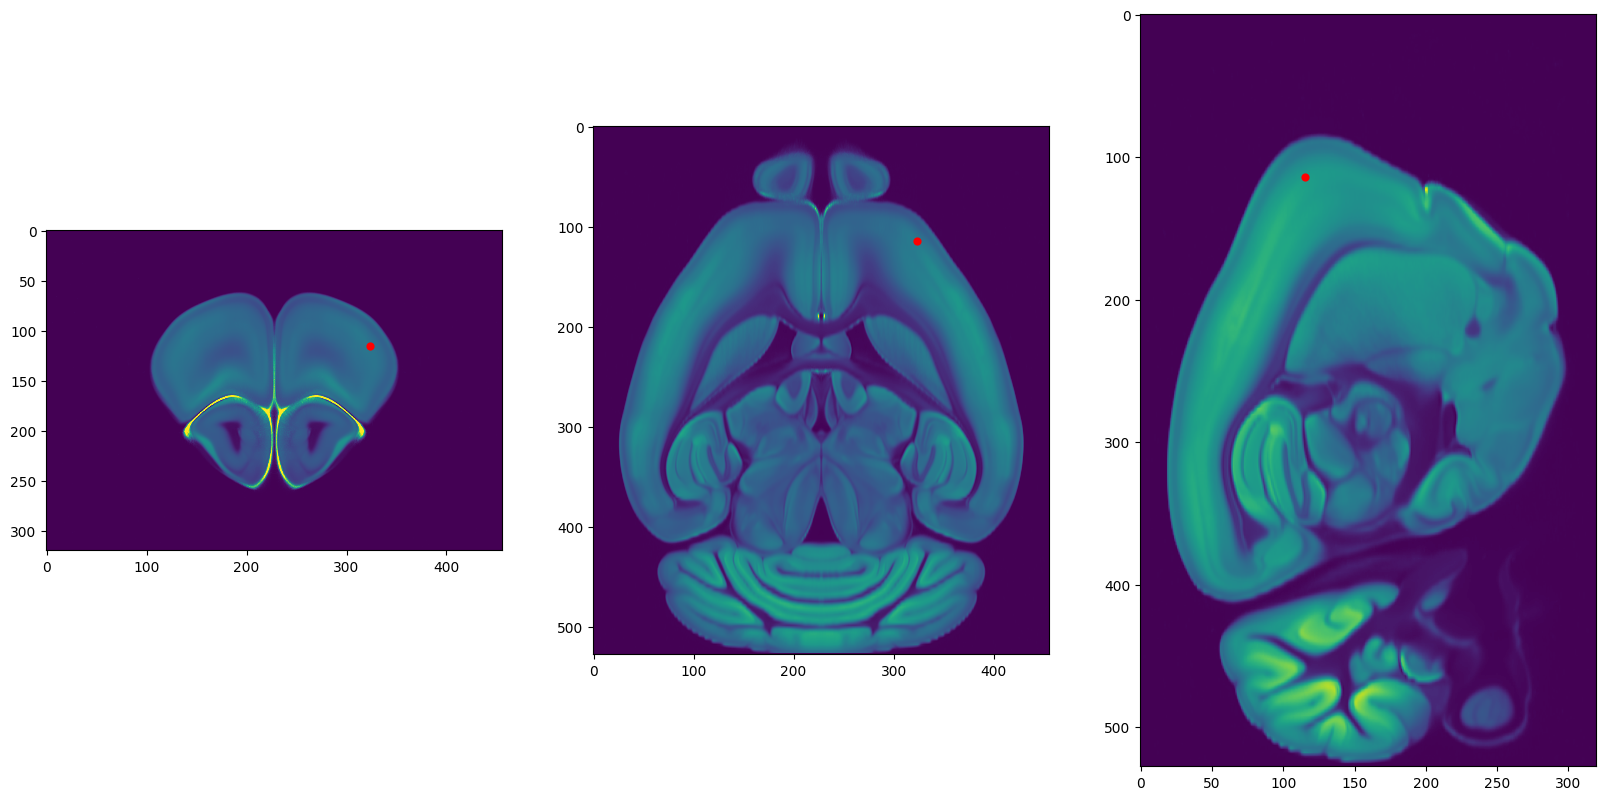

In [34]:
# Plot location in CCF
import matplotlib.pyplot as plt
from utils import plots
%matplotlib inline

# you have to have at least 2 points to register so the point is duplicated before registering
plots.plot_centroid(img, cells_ccf[0, :])

In [49]:
# for sample in sampleDict.keys()
wtSamples = [sample for sample in sampleDict.keys() if thDatasets[thDatasets["Mouse ID"] == sample]["Genotype"].isin(["WT"]).any()]
useSamples = {key: sampleDict[key] for key in wtSamples if key in sampleDict}

In [50]:
useSamples

{684821: [445, 561, 488],
 684812: [445, 561, 488],
 685903: [445, 561, 488],
 689237: [445, 561],
 689238: [445, 561, 488],
 691387: [445, 561, 488],
 691388: [445, 561, 488],
 693197: [445, 561, 488],
 693198: [445, 561, 488],
 694512: [445, 561, 488],
 695721: [445, 561, 488],
 696668: [445, 561],
 696669: [445, 561],
 698034: [445, 561, 488],
 698035: [445, 561, 488],
 698927: [445, 561],
 698928: [445, 561],
 693977: [445, 561],
 693979: [445, 561],
 693980: [445, 561],
 721832: [561, 488],
 743800: [561, 488],
 743801: [561, 488],
 754626: [561, 488],
 754627: [561],
 755809: [561, 488],
 757188: [561, 488],
 757189: [561, 488],
 757190: [561, 488],
 758792: [561, 488],
 758793: [561, 488]}

In [51]:
# for sample in sampleDict.keys()
aiSamples = [sample for sample in sampleDict.keys() if thDatasets[thDatasets["Mouse ID"] == sample]["Genotype"].isin(["Ai224"]).any()]
useSamples = {key: sampleDict[key] for key in aiSamples if key in sampleDict}

In [52]:
useSamples

{677289: [561],
 677290: [561],
 679516: [488, 561],
 679517: [561],
 679519: [561],
 685111: [561],
 692907: [488, 561],
 692909: [488, 561],
 692912: [488, 561],
 692911: [488, 561],
 692913: [488, 561],
 701750: [488, 561],
 701751: [488, 561],
 701754: [488, 561]}

In [27]:
datasets = [
 677289,
 677290,
 679516,
 679517,
 679519,
 679521,
 679518,
 685904,
 685906,
 687219,
 687220,
 685110,
 687218,
 687221,
 677291,
 691386,
 693197,
 693198,
 685111,
 687502,
 694513,
 693196,
 698034,
 692913,
 725326,
 743800,
 743801,
 743709,
 741535,
 754626,
 754627,
 755807,
 755808,
 755809,
 757188,
 757189,
 757190,
 758792,
 758793]

In [ ]:
rootDir = Path('../data')
for sample in sampleList:
    # get image info
    data_root = [file for file in rootDir.iterdir() if str(sample) in str(file)][0]
    # data_root = '../data/SmartSPIM_721832_2024-03-29_19-37-36_stitched_2024-04-05_09-23-40'
    # channel = 'Ex_488_Em_525'

    print(str(sample))
    if os.path.exists(f"{data_root}/acquisition.json"):
        # Load acquisition orientation
        with open(f"{data_root}/acquisition.json", 'r') as fp:
            data = json.load(fp)

        orientation = ["", "", ""]
        allen_orient = ["", "", ""]
        for axis in data['axes']:
            axis_val = axis['dimension']
            axis_name = axis['direction']
            orientation[int(axis_val)] = axis_name[0]
            allen_orient[int(axis_val)] = orient_lut[axis_name[0]]

        print(f"Data orientation in neuroglancer zyx: {''.join(orientation)} {tuple(allen_orient)}")
    else:
        orientation = ["SAL"]
        allen_orient = ['DV', 'AP', 'ML']
        print(f"Could not find acquisition.json. Assuming: {''.join(orientation)} {tuple(allen_orient)}")

    #set point of interest and save to .xml (this is just beacuse I don't fell like rewriting the registration function)
    cellDict = {}
    for ch in sampleDict[sample]:
        channel = channelDict[ch]
        interest_pt = {'centroid': [coordDict[sample][ch]]} #z,y,x from neuroglancer

        json_to_xml.dict_to_xml(interest_pt, centroid)

        try:
            params = {
                "cells_path": '../results/centroid.xml',
                "data_path": data_root,
                "channel": channel,
                "transforms_path": '../data/lightsheet_template_ccf_registration/',
                "orient": ''.join(orientation),
                "template_orient": 'RAS',
                "institute_abbreviation": 'AIND',
                "input_level": 0,
                "register_level": 3,
                "reg_channel": channel
            }
        except:
            params = {
                "cells_path": '../results/centroid.xml',
                "data_path": data_root,
                "channel": channel,
                "transforms_path": '../data/lightsheet_template_ccf_registration/',
                "orient": ''.join(orientation),
                "template_orient": 'RAS',
                "institute_abbreviation": 'AIND',
                "input_level": 0,
                "register_level": 3,
                "reg_channel": "Ex_639_Em_667"
            }

        _, cells_ccf = utils.transform_cells(params)
        cellDict[ch] = list(cells_ccf[0, :].astype(int))
    ccfDict[sample] = cellDict
    

    # # origin of the ML axis is opposite for registration so need to flip
    # img = ants.image_read('/data/lightsheet_template_ccf_registration/ccf_average_template_25.nii.gz')

    # for axis, label in enumerate(img.orientation):
    #     if orient_lut[label] == "ML":
    #         flip_axis = axis 

    # cells_ccf[:, flip_axis] = img.shape[flip_axis] - cells_ccf[:, flip_axis]
    # cells_ccf[0, :].astype(int)

In [2]:
#set point of interest and save to .xml (this is just beacuse I don't fell like rewriting the registration function)
interest_pt = {'centroid': [[1920, 1979, 4575]]} #z,y,x from neuroglancer
centroid = 'centroid.xml'

json_to_xml.dict_to_xml(interest_pt, centroid)

print(len(interest_pt['centroid']))

Saving cells to ../results/centroid.xml
2


In [3]:
"""
Register Cells. prameters can all be found in a datasets processing manifest. Only ones that you
really need to worry about are:
   
        image_path: location of the zarr that was annotated
        orient: orientation of the brain when imaged
"""

params = {
    "cells_path": '../results/centroid.xml',
    "data_path": data_root,
    "channel": channel,
    "transforms_path": '../data/lightsheet_template_ccf_registration/',
    "orient": ''.join(orientation),
    "template_orient": 'RAS',
    "institute_abbreviation": 'AIND',
    "input_level": 0,
    "register_level": 3,
}

_, cells_ccf = utils.transform_cells(params)

[450, 1101, 930]


In [4]:
# origin of the ML axis is opposite for registration so need to flip
img = ants.image_read('/data/lightsheet_template_ccf_registration/ccf_average_template_25.nii.gz')

for axis, label in enumerate(img.orientation):
    if orient_lut[label] == "ML":
        flip_axis = axis 

cells_ccf[:, flip_axis] = img.shape[flip_axis] - cells_ccf[:, flip_axis]

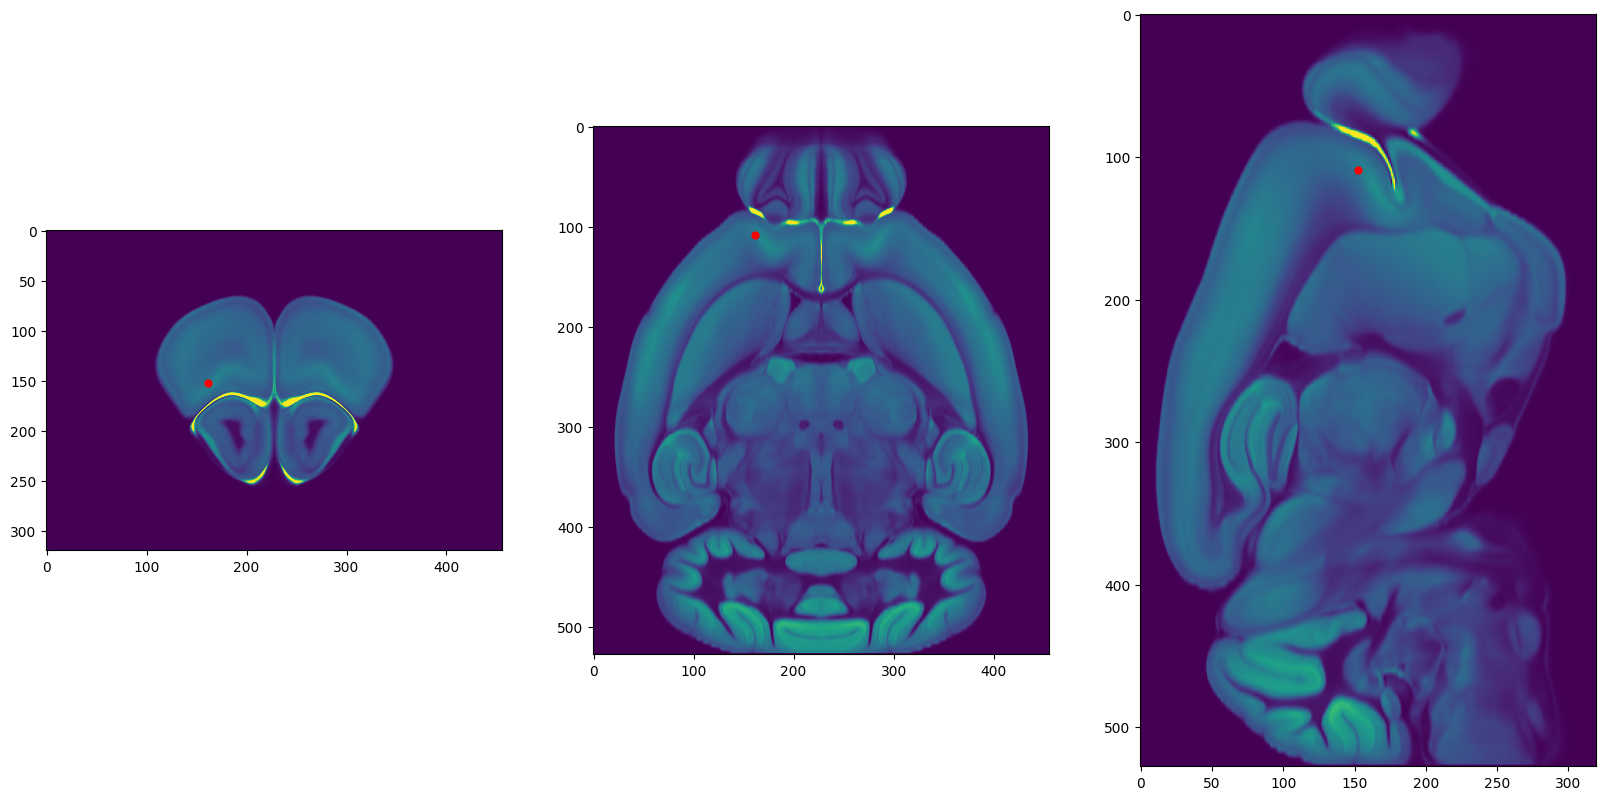

In [5]:
# Plot location in CCF
import matplotlib.pyplot as plt
from utils import plots
%matplotlib inline

img = img.numpy()

# you have to have at least 2 points to register so the point is duplicated before registering
plots.plot_centroid(img, cells_ccf[0, :])